# E-Commerce Product Review Analysis & Rating Prediction

In [ ]:
pip install missingno

In [ ]:
pip install dython pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 105.3 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled panda

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import missingno as msno
from dython.nominal import associations
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from collections import Counter
from transformers import AutoTokenizer

Authenticates with Kaggle using kagglehub, 
downloads the dataset for the target competition, 
and loads the training and test CSV files into Pandas DataFrames.

In [ ]:
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
path = kagglehub.competition_download('final-project-danit-ds-3-4')

print("Path to competition files:", path)

100%|██████████| 2.85M/2.85M [00:00<00:00, 4.48MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/final-project-danit-ds-3-4


In [ ]:
df = pd.read_csv("/root/.cache/kagglehub/competitions/final-project-danit-ds-3-4/train.csv")
test_df = pd.read_csv("/root/.cache/kagglehub/competitions/final-project-danit-ds-3-4/test.csv")

In [ ]:
df

,Id,Age,Review_Title,Review,Pos_Feedback_Cnt,Division,Department,Product_Category,Rating,Recommended
0,17274,34,Cute fall/holiday top,Love this top! the quality is magnificent and ...,1,General,Tops,Blouses,5,1
1,5921,35,NaN,NaN,0,General,Tops,Blouses,5,1
2,16479,40,Disappointed,"Sleeves were tight, was difficult to put on ?....",15,General,Tops,Blouses,2,0
3,1925,28,Gorgeous detailing,I never write reviews but this clothe is so fa...,3,General Petite,Clothes,Clothes,5,1
4,5691,39,Cute and comfortable tee!,Love this tshirt! casual but can be clotheed u...,0,General,Tops,Knits,5,1
...,...,...,...,...,...,...,...,...,...,...
14086,13641,38,Too flowy,The pattern and fabric on this clothe are very...,0,General,Clothes,Clothes,3,0
14087,2245,44,"Soft, snuggly and cute","Like the previous reviewer stated, it's more l...",2,General,Tops,Sweaters,5,1
14088,16929,44,Gorgeous!,This sweater is so lovely.. i like the fact th...,1,General Petite,Tops,Sweaters,5,1
14089,7362,54,Really versatile!,"I just love this top, it has a flattering cut,...",1,General Petite,Tops,Blouses,5,1


Drop the 'Id' column prior to EDA as it doesn't contain predictive value


In [ ]:
df = df.drop(columns='Id')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14091 entries, 0 to 14090
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               14091 non-null  int64
 1   Review_Title      11732 non-null  str  
 2   Review            13588 non-null  str  
 3   Pos_Feedback_Cnt  14091 non-null  int64
 4   Division          14080 non-null  str  
 5   Department        14080 non-null  str  
 6   Product_Category  14080 non-null  str  
 7   Rating            14091 non-null  int64
 8   Recommended       14091 non-null  int64
dtypes: int64(4), str(5)
memory usage: 5.5 MB


In [ ]:
df.describe()

,Age,Pos_Feedback_Cnt,Rating,Recommended
count,14091.000000,14091.000000,14091.000000,14091.000000
mean,43.093677,2.465474,4.197786,0.822511
std,12.176401,5.519936,1.109792,0.382096
min,18.000000,0.000000,1.000000,0.000000
25%,34.000000,0.000000,4.000000,1.000000
50%,41.000000,1.000000,5.000000,1.000000
75%,51.000000,3.000000,5.000000,1.000000
max,94.000000,122.000000,5.000000,1.000000


Identify duplicated rows

In [ ]:
df.duplicated().value_counts()

False    13985
True       106
Name: count, dtype: int64

In [ ]:
df[df.duplicated() == True]

,Age,Review_Title,Review,Pos_Feedback_Cnt,Division,Department,Product_Category,Rating,Recommended
646,35,NaN,NaN,0,General,Clothes,Clothes,5,1
800,35,NaN,NaN,0,General,Clothes,Clothes,5,1
1263,35,NaN,NaN,0,General,Clothes,Clothes,5,1
1691,31,NaN,NaN,0,General,Clothes,Clothes,5,1
1831,35,NaN,NaN,0,General,Clothes,Clothes,5,1
...,...,...,...,...,...,...,...,...,...
13805,36,NaN,NaN,0,General Petite,Clothes,Clothes,5,1
13830,46,NaN,NaN,0,General Petite,Tops,Blouses,5,1
13871,35,NaN,NaN,0,General Petite,Clothes,Clothes,5,1
13918,42,NaN,NaN,0,General,Tops,Knits,5,1


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().value_counts()

False    13985
Name: count, dtype: int64

In [ ]:
df[df['Department'].isna()]

,Age,Review_Title,Review,Pos_Feedback_Cnt,Division,Department,Product_Category,Rating,Recommended
300,34,Nubby footless tights,"These are amazing quality. i agree, size up to...",5,NaN,NaN,NaN,5,1
1371,48,NaN,NaN,0,NaN,NaN,NaN,5,1
2373,37,Love!,I am loving these. they are quite long but are...,0,NaN,NaN,NaN,5,1
3734,54,New workhorse,These tights are amazing! if i care for them w...,0,NaN,NaN,NaN,5,1
5526,49,Wardrobe staple,Love this hoodie. so soft and goes with everyt...,0,NaN,NaN,NaN,5,1
5683,43,So worth it!,Got these on sale...completely love eberjey! f...,0,NaN,NaN,NaN,5,1
9660,50,Comfy sweatshirt!,This sweatshirt is really nice! it's oversize...,0,NaN,NaN,NaN,5,1
11370,23,So soft!,I just love this hoodie! it is so soft and com...,1,NaN,NaN,NaN,5,1
12126,33,Cute itsy socks,"Love polkadots, love sparkle. these little soc...",0,NaN,NaN,NaN,5,1
12204,25,My preferred socks!!!,"I never write reviews, but these socks are so ...",0,NaN,NaN,NaN,5,1


Drop specific row containing no useful information

In [ ]:
df = df.drop(1371)

Inspect missing values specifically in the 'Knits' product category

In [ ]:
df[(df['Review'].isna()) & (df['Product_Category'] == 'Knits')]

,Age,Review_Title,Review,Pos_Feedback_Cnt,Division,Department,Product_Category,Rating,Recommended
64,49,NaN,NaN,0,General,Tops,Knits,5,1
163,37,NaN,NaN,0,General,Tops,Knits,5,1
281,40,NaN,NaN,0,General,Tops,Knits,5,1
577,63,NaN,NaN,0,General Petite,Tops,Knits,3,0
643,35,NaN,NaN,0,General Petite,Tops,Knits,5,1
...,...,...,...,...,...,...,...,...,...
12725,39,NaN,NaN,0,General,Tops,Knits,5,1
13338,32,NaN,NaN,0,General,Tops,Knits,5,1
13739,28,NaN,NaN,0,General,Tops,Knits,3,1
13879,61,NaN,NaN,0,General Petite,Tops,Knits,4,1


Missing data analysis

<Axes: >

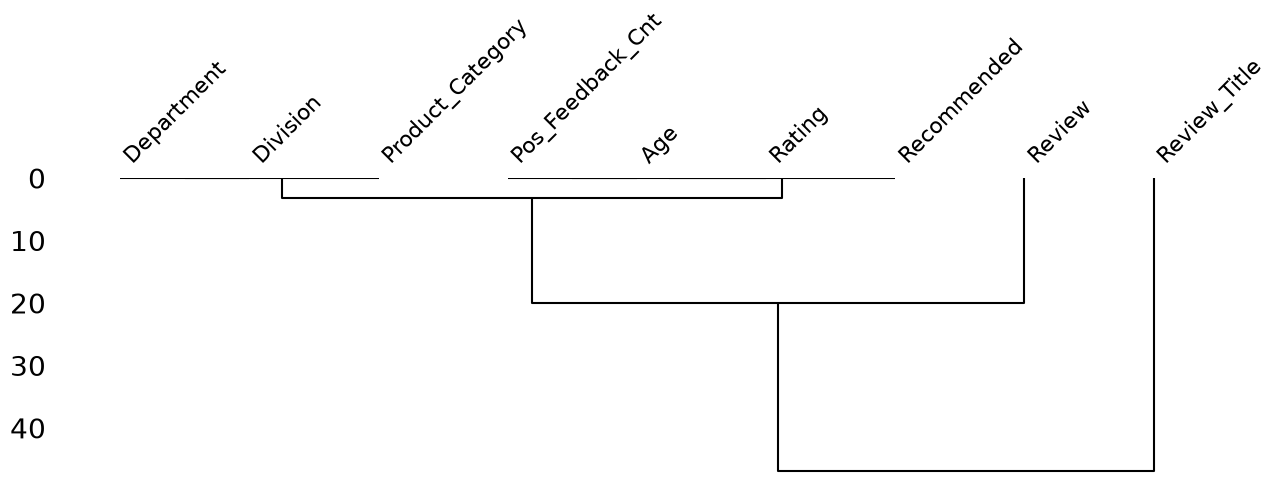

In [ ]:
msno.dendrogram(df, figsize=(15,4))

<Axes: >

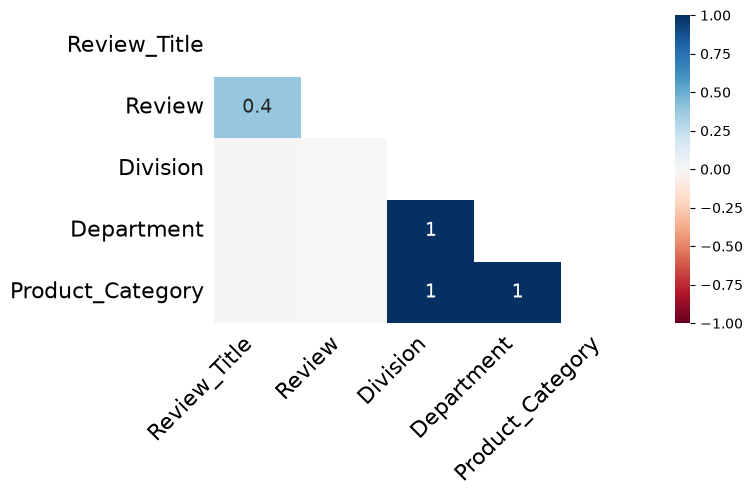

In [ ]:
msno.heatmap(df, figsize=(7,4))

<Axes: >

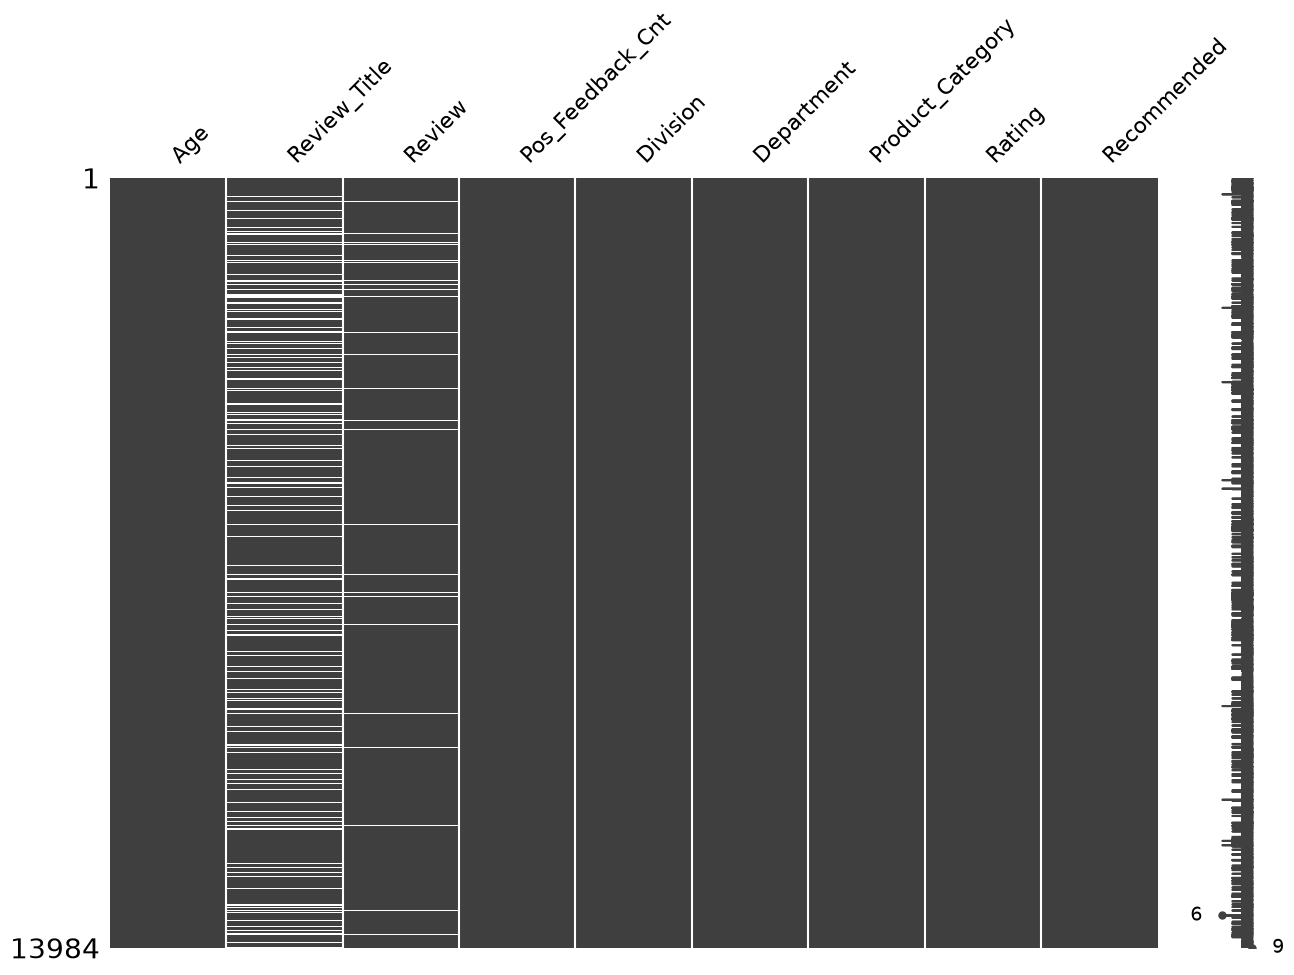

In [ ]:
msno.matrix(df, figsize=(15,10))

In [ ]:
df.info()

<class 'pandas.DataFrame'>
Index: 13984 entries, 0 to 14090
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               13984 non-null  int64
 1   Review_Title      11731 non-null  str  
 2   Review            13587 non-null  str  
 3   Pos_Feedback_Cnt  13984 non-null  int64
 4   Division          13974 non-null  str  
 5   Department        13974 non-null  str  
 6   Product_Category  13974 non-null  str  
 7   Rating            13984 non-null  int64
 8   Recommended       13984 non-null  int64
dtypes: int64(4), str(5)
memory usage: 5.6 MB


Add the 'no_review' flag to tell the model that there are no reviews

In [ ]:
df['Has_review'] = df['Review'].notna().astype(int)

Fill in the gaps in the data

In [ ]:
df['Review_Title'] = df['Review_Title'].fillna('')
df['Review'] = df['Review'].fillna('no_review')

In [ ]:
df[['Division',	'Department', 'Product_Category']] = df[['Division',	'Department', 'Product_Category']].fillna('miss')

In [ ]:
df

,Age,Review_Title,Review,Pos_Feedback_Cnt,Division,Department,Product_Category,Rating,Recommended,Has_review
0,34,Cute fall/holiday top,Love this top! the quality is magnificent and ...,1,General,Tops,Blouses,5,1,1
1,35,,no_review,0,General,Tops,Blouses,5,1,0
2,40,Disappointed,"Sleeves were tight, was difficult to put on ?....",15,General,Tops,Blouses,2,0,1
3,28,Gorgeous detailing,I never write reviews but this clothe is so fa...,3,General Petite,Clothes,Clothes,5,1,1
4,39,Cute and comfortable tee!,Love this tshirt! casual but can be clotheed u...,0,General,Tops,Knits,5,1,1
...,...,...,...,...,...,...,...,...,...,...
14086,38,Too flowy,The pattern and fabric on this clothe are very...,0,General,Clothes,Clothes,3,0,1
14087,44,"Soft, snuggly and cute","Like the previous reviewer stated, it's more l...",2,General,Tops,Sweaters,5,1,1
14088,44,Gorgeous!,This sweater is so lovely.. i like the fact th...,1,General Petite,Tops,Sweaters,5,1,1
14089,54,Really versatile!,"I just love this top, it has a flattering cut,...",1,General Petite,Tops,Blouses,5,1,1


Analyze correlation between categorical and numerical variables

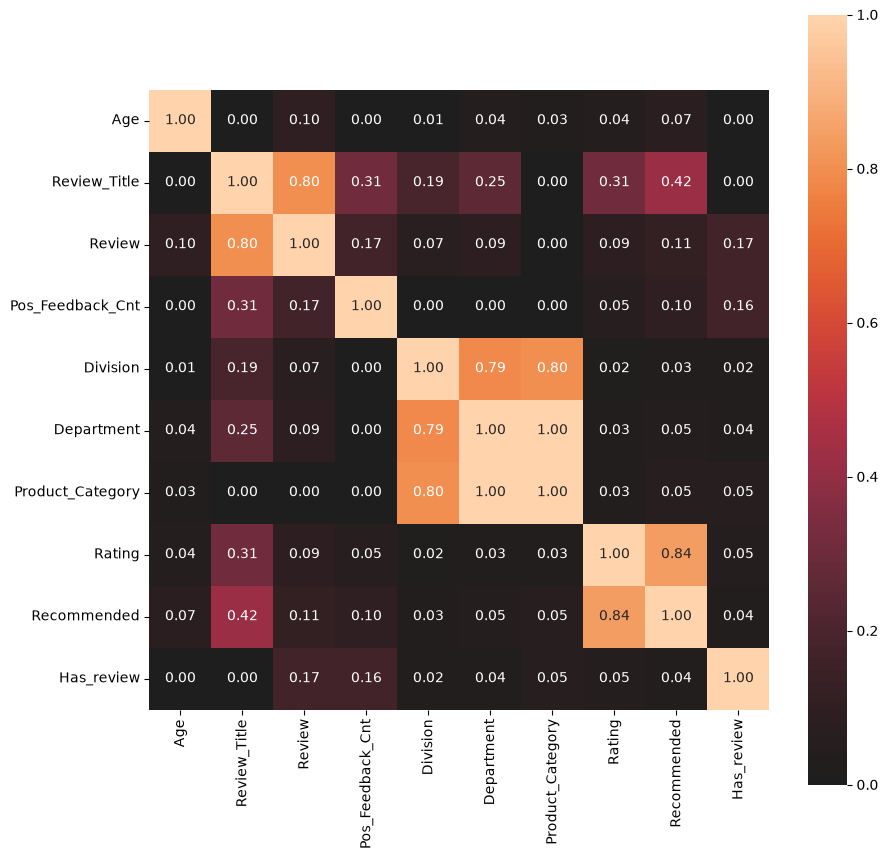

In [ ]:
results = associations(df, nominal_columns='all', plot=True, figsize=(10,10))

corr_matrix = results['corr']

Remove one of the columns with a correlation of 1. Keep the one with more unique values ​​in the column

In [ ]:
df['Product_Category'].unique()

<ArrowStringArray>
[       'Blouses',        'Clothes',          'Knits',          'Jeans',
          'Coats',       'Sweaters',         'Skirts',       'Trousers',
     'Fine gauge',         'Lounge',       'Layering',      'Intimates',
         'Shorts',       'Chemises',           'Swim',          'Sleep',
          'Trend',        'Legwear',      'Outerwear',           'miss',
 'Casual bottoms']
Length: 21, dtype: str

In [ ]:
df['Department'].unique()

<ArrowStringArray>
['Tops', 'Clothes', 'Bottoms', 'Coats', 'Intimate', 'Trend', 'miss']
Length: 7, dtype: str

In [ ]:
df = df.drop(columns='Department')

In [ ]:
df_cols = df.columns
df_cols = df_cols.drop(['Review_Title', 'Review'])

Visualization of variable distribution

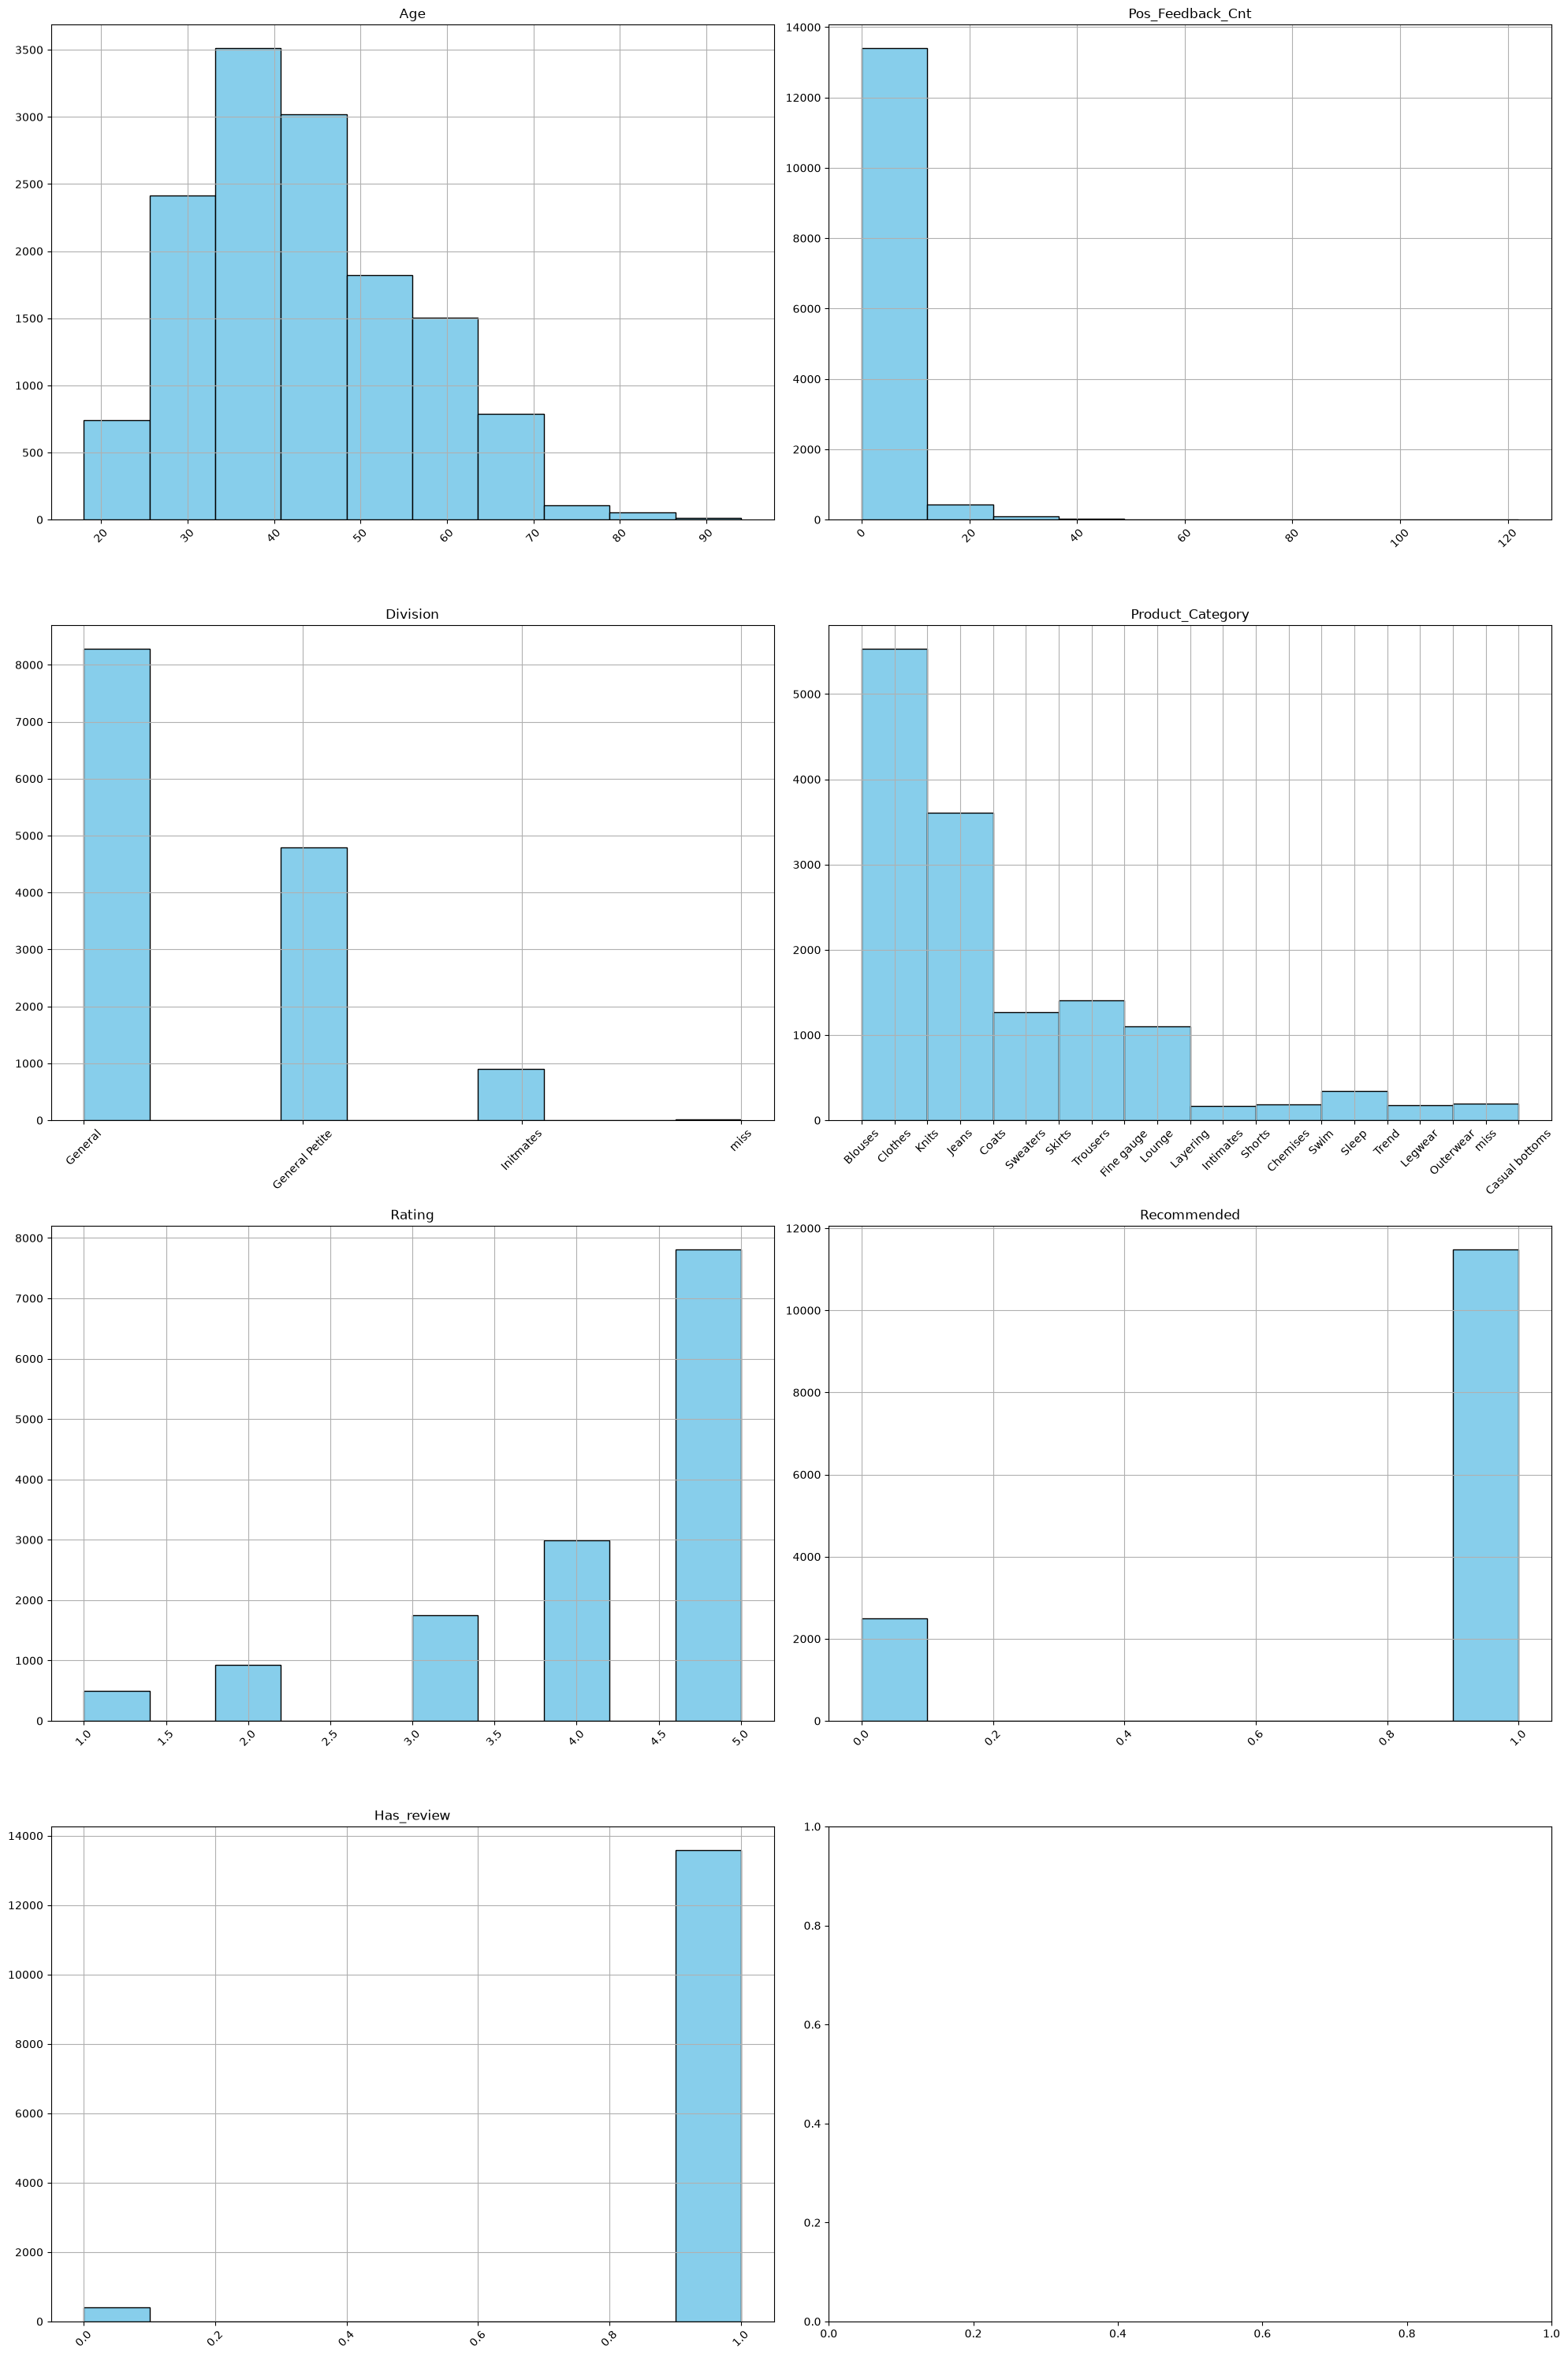

In [ ]:
def plotting_distributions(columns, df, rows):
  fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(20, 30))
  axes = axes.flatten()
  for i, col in enumerate(columns):
    ax = axes[i]

    df[col].hist(ax=ax, color='skyblue', edgecolor='black')

    ax.set_title(col, fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel('')
  plt.tight_layout()
  plt.show()

plotting_distributions(df_cols, df, 4)

To obtain a normal distribution, perform a logarithmic transformation

In [ ]:
df['Has_feedback'] = (df['Pos_Feedback_Cnt'] > 0).astype(int)
df['Pos_Feedback_Cnt'] = np.log1p(df['Pos_Feedback_Cnt'])

In [ ]:
df_cols = df.columns
df_cols = df_cols.drop(['Review_Title', 'Review'])

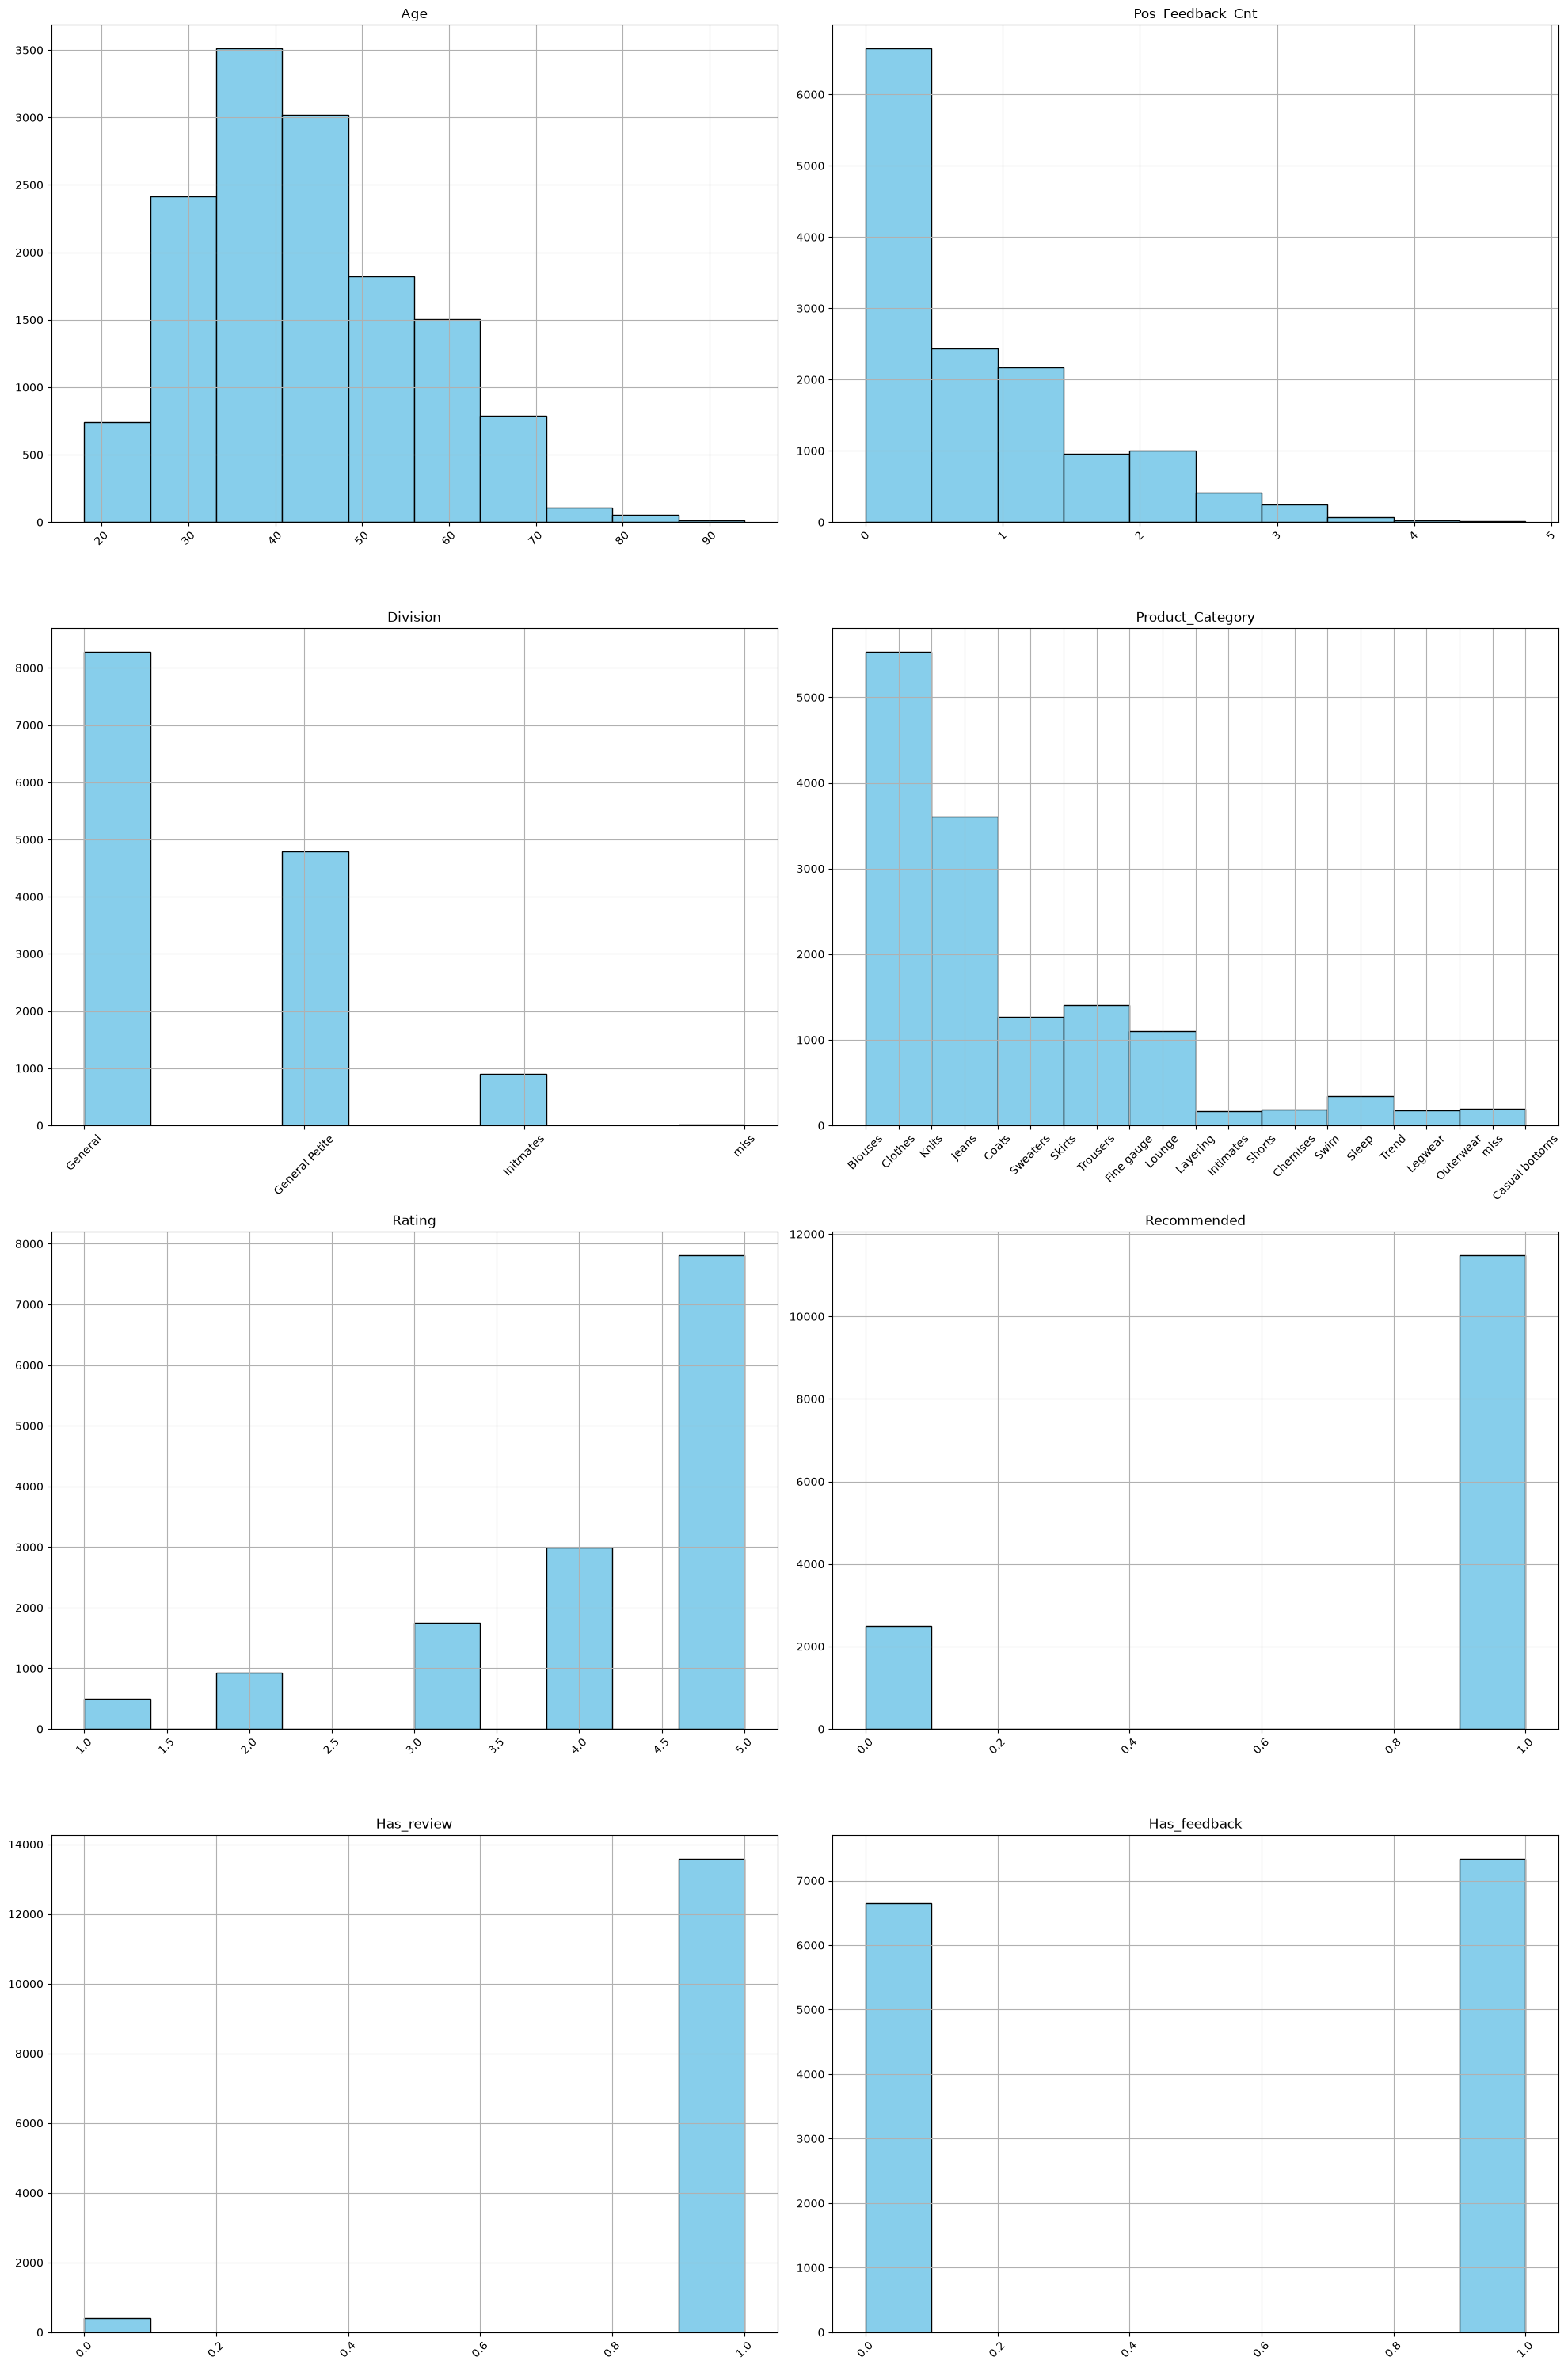

In [ ]:
plotting_distributions(df_cols, df, 4)

Feature engineering and word count distribution

Combine title and review body to analyze full textual content

In [ ]:
df['Full_text'] = df['Review_Title'] + ' ' + df['Review']

In [ ]:
df['Word_count'] = df['Full_text'].astype(str).apply(lambda x: len(x.split()))

Calculate length percentiles to guide sequence truncation choices

In [ ]:
print("90 percentile:", np.percentile(df['Word_count'], 90))
print("95 percentile:", np.percentile(df['Word_count'], 95))
print("99 percentile:", np.percentile(df['Word_count'], 99))

90 percentile: 102.0
95 percentile: 105.0
99 percentile: 110.0


Plot word count distribution with percentile markers

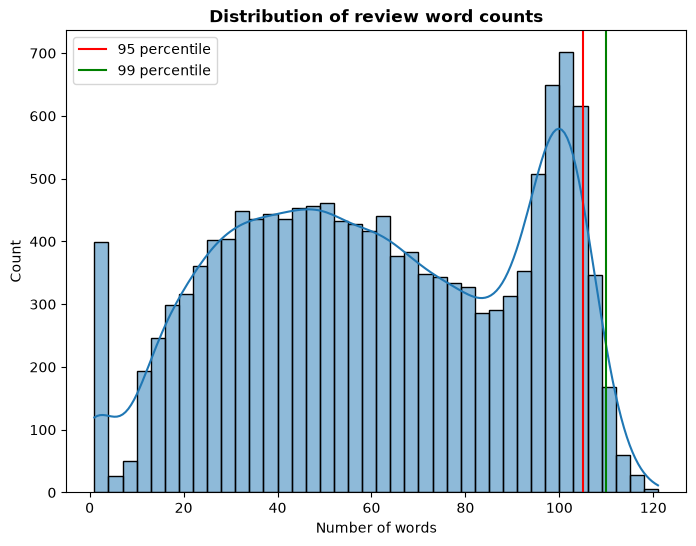

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Word_count'], kde=True, bins=40)
plt.axvline(np.percentile(df['Word_count'], 95), color='red', label='95 percentile')
plt.axvline(np.percentile(df['Word_count'], 99), color='green', label='99 percentile')
plt.title("Distribution of review word counts", fontweight='bold')
plt.xlabel("Number of words")
plt.ylabel('Count')
plt.legend()
plt.show()

Cap max_length at 110. Trimming the top 5% longest sequences significantly. Reduces tensor size and GPU memory overhead during training with minimal loss of information

Split data before vectorization to prevent data leakage from validation set

In [ ]:
df_train, df_val = train_test_split(df, test_size=0.2, shuffle=True, random_state=15)

count_vec = CountVectorizer()
bow_matrix = count_vec.fit_transform(df_train['Full_text'])

vocab_freq = pd.Series(bow_matrix.sum(axis=0).A1, index=count_vec.get_feature_names_out())

singletons = vocab_freq[vocab_freq == 1]

Identify singletons (rare words occurring exactly once)

In [ ]:
print(f"Total unique words: {len(vocab_freq)}")
print(f"Words appearing only once: {len(singletons)} ({len(singletons)/len(vocab_freq):.1%})")

Total unique words: 10713
Words appearing only once: 4535 (42.3%)


Measure cumulative word frequency and plot cumulative vocabulary coverage

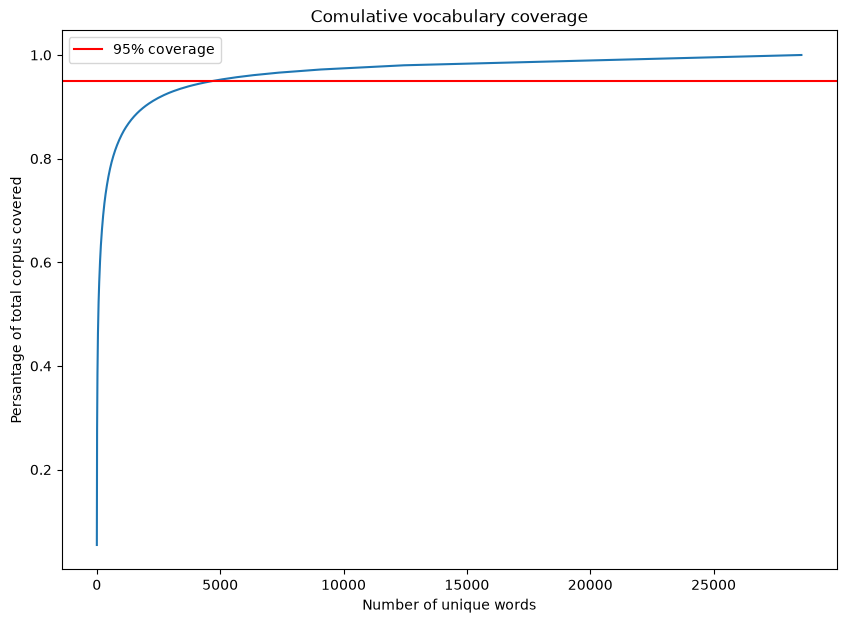

In [ ]:
all_words = " ".join(df['Review'].astype(str)).split()
total_words_counted = Counter(all_words)

counts_sorted = sorted(total_words_counted.values(), reverse=True)
comulative_coverage = np.cumsum(counts_sorted) / np.sum(counts_sorted)

plt.figure(figsize=(10,7))
plt.plot(range(1, len(counts_sorted) + 1), comulative_coverage)
plt.axhline(0.95, color='red', label="95% coverage")
plt.title('Comulative vocabulary coverage')
plt.ylabel('Persantage of total corpus covered')
plt.xlabel('Number of unique words')
plt.legend()
plt.show()

Set min_df=2 (ignore singletons to prevent overfitting) and max_tokens=5000 in TextVectorization based on the cumulative coverage analysis

Plot top 30 most frequent terms using standard English stop words

In [ ]:
clean_vec = CountVectorizer(stop_words='english')
clean_bow = clean_vec.fit_transform(df_train['Full_text'])

top_words = pd.DataFrame({
    'word': clean_vec.get_feature_names_out(),
    'count': clean_bow.sum(axis=0).A1
}).sort_values(by='count', ascending=False)

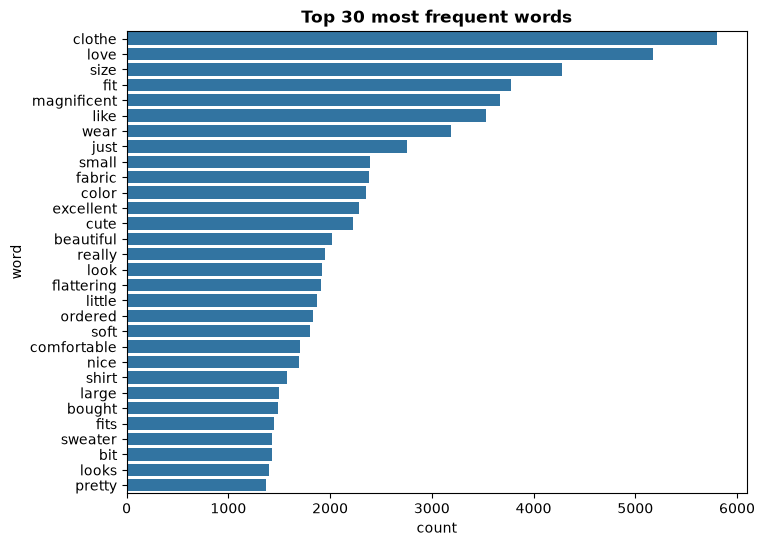

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(top_words.head(30), x='count', y='word')
plt.title("Top 30 most frequent words", fontweight='bold')
plt.show()

Filter out frequent domain-specific nouns/verbs that act as noise (do not indicate sentiment)

In [ ]:
domain_stop_words = ['clothe', 'wear', 'fabric', 'color', 'ordered', 'shirt', 'bought', 'sweater', 'looks', 'material', 'jeans', 'colors', 'did']
custom_stop_words = list(ENGLISH_STOP_WORDS.union(domain_stop_words))

Helper function to extract top N terms by target target class

In [ ]:
def get_top_words_by_class(df, tex_col_name, target_col_name, val_to_analize, my_stop_words='english', n=30):
  df_subset = df[df[target_col_name] == val_to_analize][tex_col_name]

  v = CountVectorizer(stop_words=my_stop_words)
  subset_bow = v.fit_transform(df_subset)

  counts = pd.DataFrame({
      'word': v.get_feature_names_out(),
      'count': subset_bow.sum(axis=0).A1
  }).sort_values(by='count', ascending=False).head(n)

  return counts

Compare top words between negative (0) and positive (1) recommendations

In [ ]:
neg = get_top_words_by_class(df_train, 'Full_text', 'Recommended', 0)
pos = get_top_words_by_class(df_train, 'Full_text', 'Recommended', 1)

In [ ]:
pd.concat([pos.reset_index(),neg.reset_index()], axis=1)

,index,word,count,index,word,count
0,1804,clothe,4812,908,clothe,992
1,4912,love,4664,2441,like,922
2,7411,size,3705,1671,fit,724
3,4986,magnificent,3354,2300,just,647
4,3296,fit,3051,1575,fabric,621
5,9008,wear,2811,3814,size,578
6,4772,like,2611,2510,love,510
7,3028,excellent,2175,2479,look,453
8,4486,just,2110,3879,small,447
9,1860,color,1971,3361,really,416


Preserve negation words from standard stop words to keep crucial sentiment context

In [ ]:
negations_to_keep = {'no', 'not', 'never', 'neither', 'nor', 'hardly'}
clean_english_stops = set(ENGLISH_STOP_WORDS) - negations_to_keep

final_stop_words = list(clean_english_stops.union(domain_stop_words))

In [ ]:
neg = get_top_words_by_class(df_train, 'Full_text', 'Recommended', 0, final_stop_words)
pos = get_top_words_by_class(df_train, 'Full_text', 'Recommended', 1, final_stop_words)

In [ ]:
pd.concat([pos.reset_index(),neg.reset_index()], axis=1)

,index,word,count,index,word,count
0,4905,love,4664,2800,not,1410
1,7407,size,3705,2434,like,922
2,5534,not,3624,1665,fit,724
3,4979,magnificent,3354,2293,just,647
4,3290,fit,3051,3810,size,578
5,4765,like,2611,2503,love,510
6,3023,excellent,2175,2472,look,453
7,4479,just,2110,3875,small,447
8,7530,small,1946,3358,really,416
9,2293,cute,1831,1144,cute,392


Extract top 30 bigrams to capture 2-word phrase patterns

In [ ]:
bigram_vec = CountVectorizer(ngram_range=(2,2), stop_words=final_stop_words)
bigram_bow = bigram_vec.fit_transform(df_train['Full_text'])

bigram_top = pd.DataFrame({
    'words': bigram_vec.get_feature_names_out(),
    'count': bigram_bow.sum(axis=0).A1
}).sort_values(by='count', ascending=False)

bigram_top.head(30)

,words,count
130840,true size,650
71577,love love,391
42953,fit excellently,289
70047,looks magnificent,281
111034,size small,274
134554,usual size,250
43570,fits excellently,249
103355,runs large,249
122165,super cute,246
33783,does not,234


Check relationship between review length and rating score

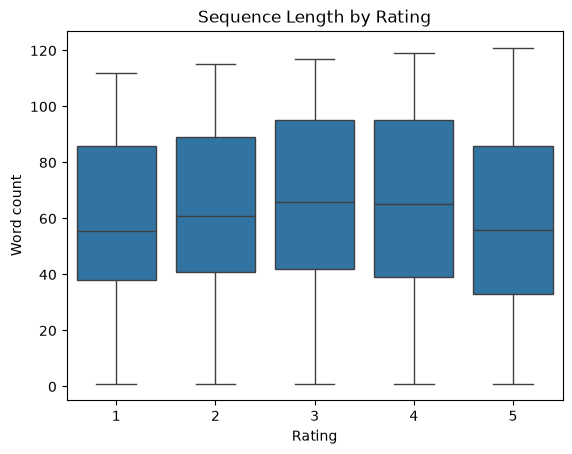

In [ ]:
sns.boxplot(data=df, x='Rating', y='Word_count')
plt.title("Sequence Length by Rating")
plt.ylabel("Word count")
plt.show()

Review word count is generally consistent across rating classes

Transformer data preprocessing

Load raw datasets

In [ ]:
df = pd.read_csv("/root/.cache/kagglehub/competitions/final-project-danit-ds-3-4/train.csv")
test_df = pd.read_csv("/root/.cache/kagglehub/competitions/final-project-danit-ds-3-4/test.csv")

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14091 entries, 0 to 14090
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Id                14091 non-null  int64
 1   Age               14091 non-null  int64
 2   Review_Title      11732 non-null  str  
 3   Review            13588 non-null  str  
 4   Pos_Feedback_Cnt  14091 non-null  int64
 5   Division          14080 non-null  str  
 6   Department        14080 non-null  str  
 7   Product_Category  14080 non-null  str  
 8   Rating            14091 non-null  int64
 9   Recommended       14091 non-null  int64
dtypes: int64(5), str(5)
memory usage: 5.6 MB


In [ ]:
df

,Age,Review_Title,Review,Pos_Feedback_Cnt,Division,Product_Category,Rating,Recommended
0,34,Cute fall/holiday top,Love this top! the quality is magnificent and ...,1,General,Blouses,5,1
1,35,NaN,NaN,0,General,Blouses,5,1
2,40,Disappointed,"Sleeves were tight, was difficult to put on ?....",15,General,Blouses,2,0
3,28,Gorgeous detailing,I never write reviews but this clothe is so fa...,3,General Petite,Clothes,5,1
4,39,Cute and comfortable tee!,Love this tshirt! casual but can be clotheed u...,0,General,Knits,5,1
...,...,...,...,...,...,...,...,...
14086,38,Too flowy,The pattern and fabric on this clothe are very...,0,General,Clothes,3,0
14087,44,"Soft, snuggly and cute","Like the previous reviewer stated, it's more l...",2,General,Sweaters,5,1
14088,44,Gorgeous!,This sweater is so lovely.. i like the fact th...,1,General Petite,Sweaters,5,1
14089,54,Really versatile!,"I just love this top, it has a flattering cut,...",1,General Petite,Blouses,5,1


In [ ]:
# Drop redundant identification columns
df = df.drop(columns=['Department', 'Id'])

# Clean missing and duplicate values
df.drop_duplicates()
df.dropna(subset=['Review_Title', 'Review', 'Division', 'Product_Category'], how='all')

# Remap 1-5 ratings to 0-4 zero-indexed labels for model compatibility
if df['Rating'].max() == 5:
  rate_map={
      1:0,
      2:1,
      3:2,
      4:3,
      5:4
  }
  df['Rating'] = df['Rating'].map(rate_map)

# Combine tabular features and text into a single structured prompt string for Transformer processing
def create_linearized_text(data):
  df_copy = data.copy(deep=True)

  df_copy[['Division', 'Product_Category']] = df_copy[['Division', 'Product_Category']].fillna('Unknown')

  review_title = df_copy['Review_Title'].fillna('').astype(str).str.strip()
  review = df_copy['Review'].fillna('').astype(str).str.strip()


  df_copy['Linearized_text'] = (
      'Title: ' + review_title + ". " +
      "Review: " + review +
      "Age: " + df_copy['Age'].astype(str) + ". " +
      "Helpful Feedback: " + df_copy['Pos_Feedback_Cnt'].astype(str) + ". " +
      "Division: " + df_copy['Division'] + ". " +
      "Category: " + df_copy['Product_Category'] + ". "
      )

  df_copy['Linearized_text'] = df_copy['Linearized_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

  return df_copy

df = create_linearized_text(df)

Perform stratified split to maintain target class distribution across splits

In [ ]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=23, stratify=df['Rating'])

Load pretrained tokenizer and calculate exact subword token lengths across linearized texts

In [ ]:
MODEL_NAME = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

token_lenght = [len(tokenizer.encode(text, truncation=False)) for text in train_df['Linearized_text']]

p95 = int(np.percentile(token_lenght, 95))
MAX_LENGTH = min(p95, 160)

In [ ]:
MAX_LENGTH

153

Set MAX_LENGTH based on 95th percentile, capped at 160 to avoid GPU padding waste